In [2]:
import duckdb as db
import pandas as pd
import numpy as np

In [3]:
PATH = "clean_flights.parquet"

In [4]:
con = db.connect()

In [5]:
total_rows = con.execute(
    f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    """
).fetchone()[0]

print(f"Totoal flights: {total_rows}")

Totoal flights: 36367047


## Initial Weather EDA

In [6]:
weather_stats = con.execute(
    f""" 
    SELECT
        COUNT(*) AS total_flights,
        SUM(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_flights,
        AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_probability,
        AVG(WeatherDelay) AS avg_weather_minutes,
        MEDIAN(WeatherDelay) AS med_weather_minutes
    FROM read_parquet('{PATH}')
    """).df()

weather_stats

,total_flights,weather_flights,weather_probability,avg_weather_minutes,med_weather_minutes
0,36367047,415640.0,0.011429,4.181365,0.0


Weather-related delays occur in only about 1% of flights, indicating that weather is a relatively rare but potentially impactful disruption factor.

In [7]:
avg_weather_delay_min = con.execute(f"""
    SELECT AVG(WeatherDelay)
    FROM read_parquet('{PATH}')
    WHERE WeatherDelay > 0
""").fetchone()[0]

med_weather_delay_min = con.execute(f"""
    SELECT MEDIAN(WeatherDelay)
    FROM read_parquet('{PATH}')
    WHERE WeatherDelay > 0
""").fetchone()[0]

print(avg_weather_delay_min, med_weather_delay_min)

69.69598209989414 34.0


In [8]:
df = con.execute(f"""
    SELECT 
        WeatherDelay
    FROM read_parquet('{PATH}')
    USING SAMPLE 1000000 ROWS""").df()

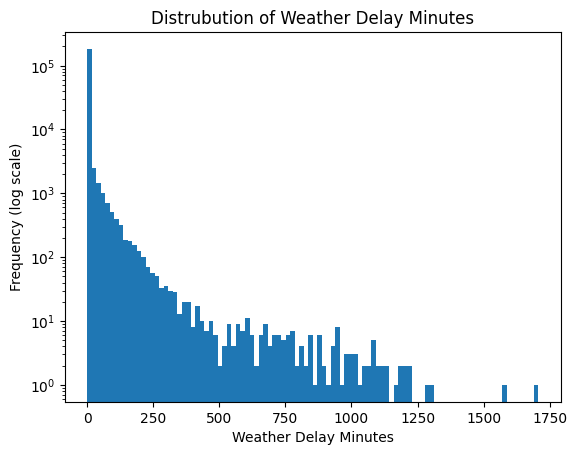

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["WeatherDelay"], bins = 100, log = True)
plt.title("Distribution of Weather Delay Minutes")
plt.xlabel("Weather Delay Minutes")
plt.ylabel("Frequency (log scale)")
plt.show()

In [10]:
df1 = con.execute(f"""
    SELECT
        WeatherDelay
    FROM read_parquet('{PATH}')
    WHERE WeatherDelay > 0
    USING SAMPLE 1000000 ROWS
""").df()

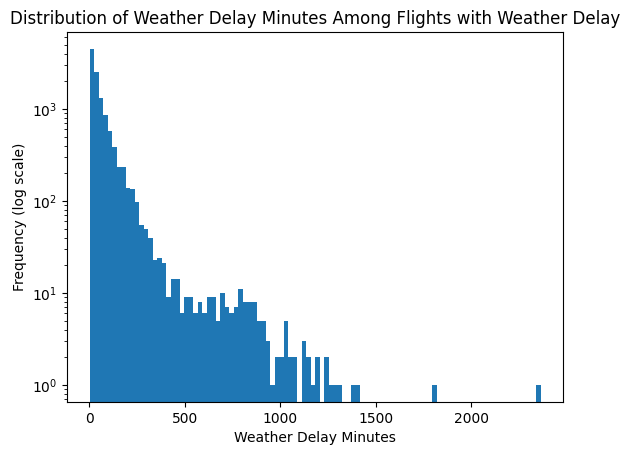

In [38]:
import matplotlib.pyplot as plt

plt.hist(df1["WeatherDelay"], bins = 100, log = True)
plt.title("Distribution of Weather Delay Minutes Among Flights with Weather Delay")
plt.xlabel("Weather Delay Minutes")
plt.ylabel("Frequency (log scale)")
plt.show()

In [26]:
monthly_weather = con.execute(f"""
    SELECT
        Month,
        AVG(WeatherDelay) AS avg_weather_delay,
        COUNT(*) * 1.0 / (
            SELECT COUNT(*) 
            FROM read_parquet('{PATH}') 
            WHERE WeatherDelay > 0
        ) AS share_of_weather_flights
    FROM read_parquet('{PATH}')
    WHERE WeatherDelay > 0
    GROUP BY Month
    ORDER BY avg_weather_delay DESC
""").df()

monthly_weather

,Month,avg_weather_delay,share_of_weather_flights
0,12,83.534078,0.070424
1,1,79.457501,0.094286
2,2,75.004066,0.075746
3,11,72.925721,0.046124
4,10,70.572674,0.042508
5,3,68.744797,0.065436
6,4,67.660040,0.065718
7,5,67.333995,0.094589
8,8,67.082310,0.116014
9,6,65.051921,0.125022


### Kruskal–Wallis Test (Nonparametric ANOVA)

Tests whether the distributions differ across months without assuming normality.

In [30]:
from scipy.stats import kruskal

weather_df = con.execute(f"""
SELECT
    Month,
    WeatherDelay
FROM read_parquet('{PATH}')
WHERE WeatherDelay > 0
USING SAMPLE 200000 ROWS
""").df()

In [28]:
groups = [
    weather_df[weather_df["Month"] == m]["WeatherDelay"]
    for m in sorted(weather_df["Month"].unique())
]

stat, p = kruskal(*groups)

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

Kruskal-Wallis statistic: 9.947081758502957
p-value: 0.5351534005744609


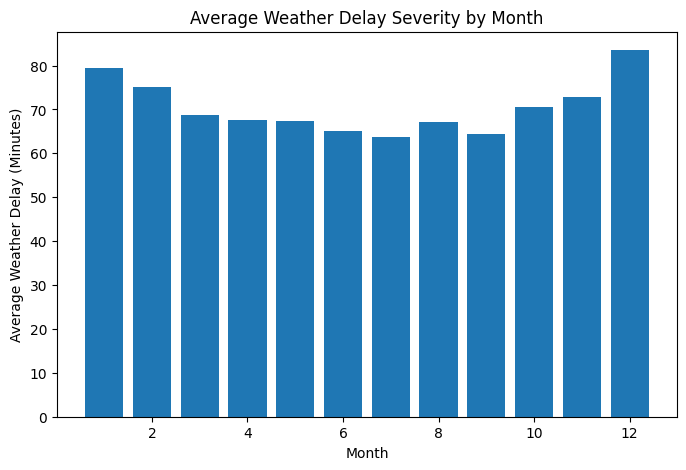

In [29]:
plt.figure(figsize=(8,5))
plt.bar(monthly_weather["Month"], monthly_weather["avg_weather_delay"])
plt.xlabel("Month")
plt.ylabel("Average Weather Delay (Minutes)")
plt.title("Average Weather Delay Severity by Month")
plt.show()

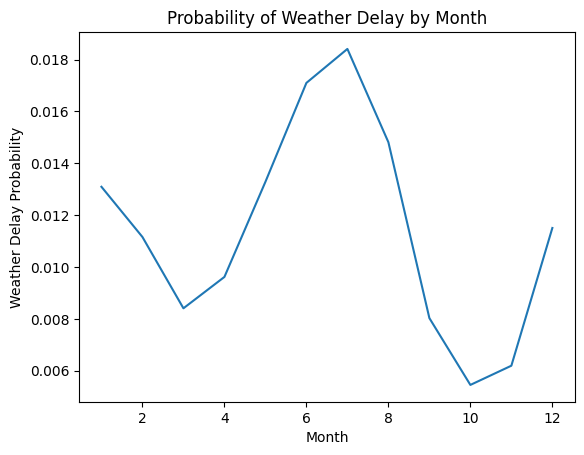

In [ ]:
plt.plot(monthly_weather["Month"], monthly_weather["weather_frequency"])
plt.title("Probability of Weather Delay by Month")
plt.xlabel("Month")
plt.ylabel("Weather Delay Probability")
plt.show()

## Analyze Weather Delay by Severity

In [12]:
severity_weather = con.execute(f"""
SELECT
    CASE
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 15 THEN 'OnTime (<= 15 min delay)'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 60 THEN 'Mild (<= 60 min delay)'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 180 THEN 'Moderate (<= 180 min delay)'
        ELSE 'Severe (> 180 min delay)'
    END AS DelayCategory,
    COUNT(*) AS total_flights,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS pct_of_total,
    AVG(WeatherDelay) AS avg_weather,
    AVG(CarrierDelay) AS avg_carrier,
    AVG(NASDelay) AS avg_nas,
    AVG(LateAircraftDelay) AS avg_late_aircraft
FROM read_parquet('{PATH}')
GROUP BY DelayCategory
ORDER BY total_flights DESC
""").df()

severity_weather

,DelayCategory,total_flights,pct_of_total,avg_weather,avg_carrier,avg_nas,avg_late_aircraft
0,OnTime (<= 15 min delay),28344047,0.779388,0.154459,3.623655,9.911550,1.274272
1,Mild (<= 60 min delay),5415578,0.148914,0.900536,10.158056,9.417340,9.367737
2,Moderate (<= 180 min delay),2130170,0.058574,5.220746,30.331335,16.216207,40.151921
3,Severe (> 180 min delay),477252,0.013123,29.463385,141.927775,31.619267,120.633526


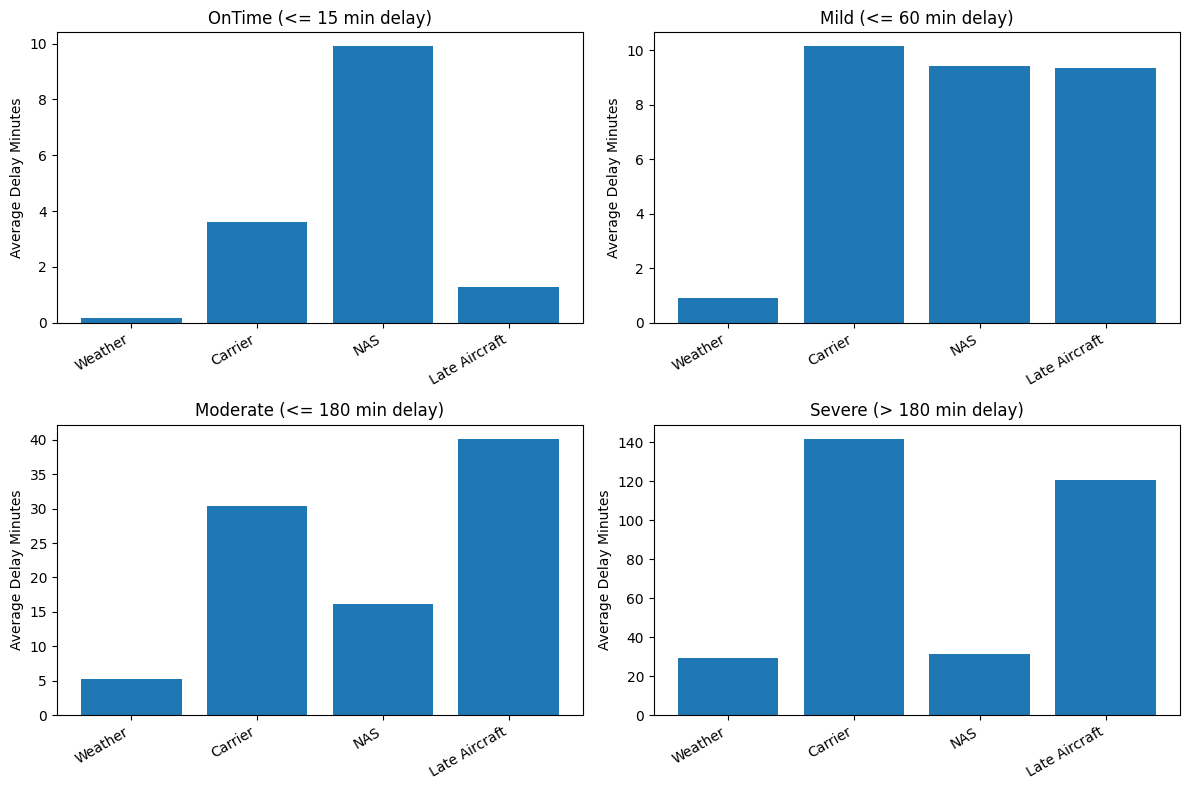

In [13]:
categories = [
    "OnTime (<= 15 min delay)",
    "Mild (<= 60 min delay)",
    "Moderate (<= 180 min delay)",
    "Severe (> 180 min delay)"
]

cause_cols = ["avg_weather", "avg_carrier", "avg_nas", "avg_late_aircraft"]
cause_labels = ["Weather", "Carrier", "NAS", "Late Aircraft"]

plt.figure(figsize=(12, 8))

for i, cat in enumerate(categories, 1):
    row = severity_weather[severity_weather["DelayCategory"] == cat].iloc[0]
    values = [row[c] for c in cause_cols]

    plt.subplot(2, 2, i)
    plt.bar(cause_labels, values)
    plt.title(cat)
    plt.ylabel("Average Delay Minutes")
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

Question: For each delay type, the average, weather, carrier, NAS, and Late aircraft are all much lower than the defined type of delay. Is is possible that each flight delay is a comination of types of delays?

In [ ]:
check_all = con.execute(f"""
SELECT
    CASE
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 15 THEN 'OnTime'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 60 THEN 'Mild'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 180 THEN 'Moderate'
        ELSE 'Severe'
    END AS DelayCategory,

    AVG(GREATEST(DepDelayMinutes, ArrDelayMinutes)) AS avg_total_delay,

    AVG(
        COALESCE(CarrierDelay, 0) +
        COALESCE(WeatherDelay, 0) +
        COALESCE(NASDelay, 0) +
        COALESCE(LateAircraftDelay, 0) +
        COALESCE(SecurityDelay, 0)
    ) AS avg_sum_components

FROM read_parquet('{PATH}')
GROUP BY DelayCategory
ORDER BY DelayCategory;
""").df()

check_all

,DelayCategory,avg_total_delay,avg_sum_components
0,Mild,31.473479,23.139704
1,Moderate,99.742374,92.081188
2,OnTime,1.838893,0.072372
3,Severe,332.507195,323.929415


## Weather Analysis by Airport

### Weather Frequency by Airport

In [14]:
airport_weather_conditional = con.execute(f"""
SELECT
    Origin,
    OriginCityName AS city_state_name,                                          
    COUNT(*) AS total_flights,
    AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_delay_frequency,
    AVG(CASE WHEN WeatherDelay > 0 THEN WeatherDelay END) AS avg_weather_delay_when_occurs
FROM read_parquet('{PATH}')
GROUP BY Origin, OriginCityName
HAVING COUNT(*) > 10000
ORDER BY avg_weather_delay_when_occurs DESC
LIMIT 30;
""").df()

airport_weather_conditional

,Origin,city_state_name,total_flights,weather_delay_frequency,avg_weather_delay_when_occurs
0,SUN,"Sun Valley/Hailey/Ketchum, ID",10839,0.024080,141.980843
1,GTF,"Great Falls, MT",14313,0.015510,124.729730
2,MRY,"Monterey, CA",23105,0.011123,121.439689
3,FLG,"Flagstaff, AZ",10711,0.016245,120.568966
4,RDM,"Bend/Redmond, OR",36709,0.015773,116.412781
5,SAF,"Santa Fe, NM",12617,0.029643,116.056150
6,PSC,"Pasco/Kennewick/Richland, WA",30858,0.014939,112.683297
7,MOT,"Minot, ND",13940,0.031349,111.631579
8,IDA,"Idaho Falls, ID",20836,0.020301,110.316785
9,MFR,"Medford, OR",32590,0.013164,108.247086


### Plot Map of Airports and Weather Delay Severity

In [15]:
airports = pd.read_csv("airports.csv")

airports = airports.rename(columns={
    "IATA": "airport",
    "LATITUDE": "lat",
    "LONGITUDE": "lon"
})

airports = airports[["airport", "lat", "lon"]]

airports.head()

,airport,lat,lon
0,ABQ,35.040222,-106.609194
1,ANC,61.174320,-149.996186
2,ATL,33.640444,-84.426944
3,AUS,30.194533,-97.669872
4,BDL,41.938874,-72.683228


In [16]:
merged = airport_weather_conditional.merge(
    airports,
    left_on="Origin",
    right_on="airport",
    how="inner"
)

merged.head()

,Origin,city_state_name,total_flights,weather_delay_frequency,avg_weather_delay_when_occurs,airport,lat,lon
0,SUN,"Sun Valley/Hailey/Ketchum, ID",10839,0.024080,141.980843,SUN,43.504841,-114.296590
1,GTF,"Great Falls, MT",14313,0.015510,124.729730,GTF,47.482002,-111.370685
2,MRY,"Monterey, CA",23105,0.011123,121.439689,MRY,36.586982,-121.842948
3,FLG,"Flagstaff, AZ",10711,0.016245,120.568966,FLG,35.138455,-111.671218
4,RDM,"Bend/Redmond, OR",36709,0.015773,116.412781,RDM,44.254067,-121.149963


In [22]:
import plotly.express as px
import plotly.io as pio

fig = px.scatter_geo(
    merged,
    lat="lat",
    lon="lon",
    scope="usa",
    hover_name="city_state_name",
    size="weather_delay_frequency",                 # bubble size = frequency
    color="avg_weather_delay_when_occurs",          # color = severity
    projection="albers usa",
    title="US Airports: Weather Delay Hotspots (2020–2025)",
    color_continuous_scale="Reds"
)

fig.update_layout(
    title="Weather Delay Hotspots When a Weather Delay Occurs (2020-2025)",
    height=700
)
pio.renderers.default = "browser"
fig.write_html("WeatherDelayMap.html", include_plotlyjs="cdn")
fig.show()

### Animation of U.S. Map by Month

In [33]:
MIN_TOTAL_FLIGHTS = 10000

airport_weather_ym = con.execute(f"""
WITH big_airports AS (
  SELECT Origin AS airport
  FROM read_parquet('{PATH}')
  GROUP BY Origin
  HAVING COUNT(*) > {MIN_TOTAL_FLIGHTS}
)

SELECT
    Origin AS airport,
    OriginCityName AS AirportCity,
    strftime(FlightDate, '%Y-%m') AS ym,
    COUNT(*) AS total_flights,
    AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_frequency,
    AVG(CASE WHEN WeatherDelay > 0 THEN WeatherDelay END) AS avg_weather_when_occurs
FROM read_parquet('{PATH}')
WHERE Origin IN (SELECT airport FROM big_airports)
GROUP BY airport, AirportCity, ym
ORDER BY ym, airport
""").df()

In [34]:
airports = pd.read_csv("airports.csv").rename(columns={
    "IATA": "airport",
    "LATITUDE": "lat",
    "LONGITUDE": "lon"
})[["airport", "lat", "lon", "STATE"]]

merged_ym = airport_weather_ym.merge(airports, on="airport", how="inner")

In [36]:
fig = px.scatter_geo(
    merged_ym,
    lat="lat",
    lon="lon",
    scope="usa",
    hover_name="AirportCity",
    hover_data={
        "airport": True,
        "STATE": True,
        "ym": True,
        "total_flights": True,
        "weather_frequency": ':.3%',
        "avg_weather_when_occurs": ':.1f',
        "lat": False,
        "lon": False
    },
    size="weather_frequency",                 # bubble size = frequency
    color="avg_weather_when_occurs",          # color = severity (conditional)
    color_continuous_scale=px.colors.sequential.Reds,
    animation_frame="ym",
    projection="albers usa",
    title="US Airports: Weather Delay Hotspots Over Time (2020–2025)"
)

# Keep the color scale consistent across frames
fig.update_coloraxes(
    cmin=merged_ym["avg_weather_when_occurs"].quantile(0.05),
    cmax=merged_ym["avg_weather_when_occurs"].quantile(0.95)
)

fig.update_layout(
        title="Weather Delay Hotspots by Month (2020–2025)",
        height=700)
fig.write_html("WeatherDelayAnimationMap.html",
        include_plotlyjs="cdn",
        auto_play=False)
fig.show(renderer="browser")

## Chi Squared tested severity conditional on weather

In [37]:
from scipy.stats import chi2_contingency

weather_month_df = con.execute(f"""
SELECT
    Month,
    CASE 
        WHEN WeatherDelay > 0 THEN 1
        ELSE 0
    END AS WeatherPresent
FROM read_parquet('{PATH}')
USING SAMPLE 200000 ROWS
""").df()

ct_weather_month = pd.crosstab(
    weather_month_df["Month"],
    weather_month_df["WeatherPresent"]
)

chi2, p, dof, expected = chi2_contingency(ct_weather_month)

n = ct_weather_month.to_numpy().sum()
k = min(ct_weather_month.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

pd.DataFrame({
    "chi2": [chi2],
    "dof": [dof],
    "p_value": [p],
    "cramers_v": [cramers_v],
    "n": [n]
})

,chi2,dof,p_value,cramers_v,n
0,357.522506,11,6.199500e-70,0.04228,200000
